# Drzewa decyzyjne

Podczas zajęć pakiet scikit-learn (sklearn) będzie używany do budowania drzew decyzyjnych na podstawie danych, testowania tych drzew oraz wykorzystywania ich do klasyfikacji.

In [1]:
from sklearn.datasets import load_iris
from sklearn import tree
import matplotlib.pyplot as plt
iris = load_iris()  #wczytanie danych

Tworzenie obiektu drzewa.

http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

In [2]:
mytree1 = tree.DecisionTreeClassifier()

Uczenie klasyfikatora drzewa decyzyjnego na podstawie danych treningowych.

In [3]:
mytree1.fit(iris.data, iris.target)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

Parametry konfiguracyjne drzewa można odczytać za pomocą metody `get_params`.

In [4]:
mytree1.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

Klasyfikacja przykładowego wektora cech.

In [5]:
result_class = mytree1.predict([[2,3,4,5]])
print(iris.target_names[result_class])

['versicolor']


Można również uzyskać prawdopodobieństwa klas dla danego przykładu.

In [6]:
mytree1.predict_proba([[2,3,4,5]])

array([[0., 1., 0.]])

# Struktura drzewa

Funkcja `plot_tree` umożliwia narysowanie wytrenowanego drzewa.

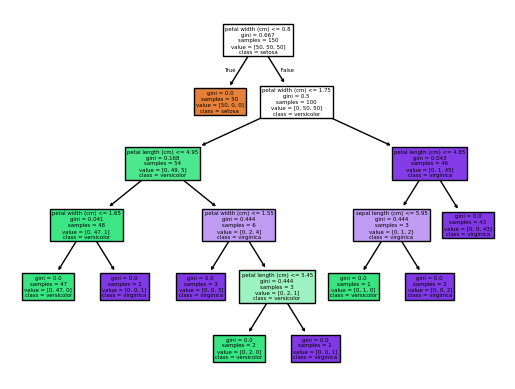

In [7]:
tree.plot_tree(mytree1,filled=True, feature_names=iris.feature_names,class_names=iris.target_names)
plt.show()

Struktura drzewa jest zapisywana w atrybucie `tree_`. Można tam znaleźć informacje o liczbie węzłów oraz tabele zawierające:

* dla każdego węzła wewnętrznego: indeksy lewego i prawego węzła potomnego, indeks atrybutu wybranego dla reguły decyzyjnej w tym węźle oraz wartość progową dla tego atrybutu,

* dla każdego liścia: wartości nieistotne.

Przeanalizuj strukturę swojego drzewa (`mytree1`).

In [8]:
print("Liczba wezlow: ", mytree1.tree_.node_count)
print("Indeksy lewych potomkow:", mytree1.tree_.children_left)
print("Indeksy prawych potomkow:",mytree1.tree_.children_right)
print("Wybrane atrybuty:", mytree1.tree_.feature)
print("Wartosci progowe:", mytree1.tree_.threshold)

Liczba wezlow:  17
Indeksy lewych potomkow: [ 1 -1  3  4  5 -1 -1  8 -1 10 -1 -1 13 14 -1 -1 -1]
Indeksy prawych potomkow: [ 2 -1 12  7  6 -1 -1  9 -1 11 -1 -1 16 15 -1 -1 -1]
Wybrane atrybuty: [ 3 -2  3  2  3 -2 -2  3 -2  2 -2 -2  2  0 -2 -2 -2]
Wartosci progowe: [ 0.80000001 -2.          1.75        4.95000005  1.65000004 -2.
 -2.          1.55000001 -2.          5.45000005 -2.         -2.
  4.85000014  5.95000005 -2.         -2.         -2.        ]


**Zadanie 1. (1 pkt)**

Korzystając z informacji o strukturze drzewa zawartych w atrybucie `tree_`, wypisz indeksy wszystkich liści skonstruowanego drzewa.

In [9]:
#Miejsce na rozwiązanie
leaves = [
    i for i in range(mytree1.tree_.node_count)
    if mytree1.tree_.children_left[i] == -1 and mytree1.tree_.children_right[i] == -1
]

print(leaves)

[1, 5, 6, 8, 10, 11, 14, 15, 16]


# Testowanie drzewa decyzyjnego

**Na podstawie oddzielnego zestawu danych**

Zbiór danych jest dzielony na dane treningowe i testowe (`train_test_split`). Metoda `score` zwraca dokładność klasyfikacji. Za pomocą funkcji `confusion_matrix` można dokładnie sprawdzić, jakie są wyniki klasyfikacji w zależności od klasy. Funkcja ta zwraca macierz, której element (i, j) zawiera liczbę przykładów i-tej klasy zaklasyfikowanych do j-tej klasy.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix #, accuracy_score
data_train, data_test, target_train, target_test = train_test_split(iris.data, iris.target, test_size=0.4, random_state=0)
mytree1.fit(data_train, target_train)
print(mytree1.score(data_test,target_test), " spośród przykładów sklasyfikowano prawidłowo.")
confusion_matrix(target_test, mytree1.predict(data_test))

0.95  spośród przykładów sklasyfikowano prawidłowo.


array([[16,  0,  0],
       [ 0, 22,  1],
       [ 0,  2, 19]])

**Podczas procedury walidacji krzyżowej**

Zbiór danych jest dzielony na k podzbiorów. Uczenie i testowanie powtarza się k razy. W każdej iteracji 1 z k podzbiorów jest używany do testowania, a wszystkie pozostałe do uczenia (k-krotna walidacja krzyżowa). Wyniki są uśredniane (`cross_val_score`).

In [11]:
from sklearn.model_selection import cross_val_score
results = cross_val_score(mytree1, iris.data, iris.target, cv=5)

Wyniki testów uzyskujemy z pojedynczych przebiegów walidacyjnych, a także uśredniony wynik z 95% przedziałem ufności. Rzeczywisty wynik mieści się w tym przedziale z prawdopodobieństwem 0,95.

In [12]:
print("Dokładność klasyfikacji dla poszczególnych przebiegów walidacyjnych: ", results)
print("Średnia dokładność klasyfikacji: %0.2f (+/- %0.2f)" % (results.mean(), results.std() * 2))

Dokładność klasyfikacji dla poszczególnych przebiegów walidacyjnych:  [0.96666667 0.96666667 0.9        0.93333333 1.        ]
Średnia dokładność klasyfikacji: 0.95 (+/- 0.07)


W wyniku walidacji krzyżowej każdy przykład jest uwzględniany w zestawie testowym jednokrotnie. Wyniki predykcji dla poszczególnych przykładów można odczytać za pomocą funkcji `cross_val_predict`. Funkcja ta, podobnie jak `cross_val_score`, przeprowadza walidację krzyżową, ale zwraca wyniki klasyfikacji poszczególnych przykładów zamiast dokładności uzyskanej w kolejnych iteracjach.

In [13]:
from sklearn.model_selection import cross_val_predict
cross_val_predict(mytree1, iris.data, iris.target, cv=5)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

**Zadanie 2. (1 pkt)**

Podaj liczbę i indeksy przykładów, które zostały błędnie sklasyfikowane podczas 10-krotnej walidacji krzyżowej.

In [14]:
#Miejsce na rozwiązanie
pred = cross_val_predict(mytree1, iris.data, iris.target, cv=10)

wrong = [i for i in range(len(iris.target)) if pred[i] != iris.target[i]]

print("Liczba błędnie sklasyfikowanych przykładów:", len(wrong))
print("Indeksy błędnie sklasyfikowanych przykładów:", wrong)


Liczba błędnie sklasyfikowanych przykładów: 7
Indeksy błędnie sklasyfikowanych przykładów: [70, 77, 83, 106, 119, 129, 138]


**Zadanie 3 (1 pkt)**

Wykonaj 10-krotną walidację krzyżową, aby przetestować dwa drzewa różniące się zastosowanym kryterium wyboru atrybutów: przyrostem informacji (`criterion = 'entropy'`) lub Gini index (`criterion ='gini'`). Porównaj jakość klasyfikacji w obu przypadkach.

In [15]:
#Miejsce na rozwiązanie
from sklearn.tree import DecisionTreeClassifier

tree_entropy = DecisionTreeClassifier(criterion='entropy')
tree_gini = DecisionTreeClassifier(criterion='gini')

scores_entropy = cross_val_score(tree_entropy, iris.data, iris.target, cv=10)
scores_gini = cross_val_score(tree_gini, iris.data, iris.target, cv=10)

print("Entropy - wyniki:", scores_entropy)
print("Entropy - średnia dokładność: %0.4f (+/- %0.4f)" % (scores_entropy.mean(), scores_entropy.std() * 2))

print("Gini - wyniki:", scores_gini)
print("Gini - średnia dokładność: %0.4f (+/- %0.4f)" % (scores_gini.mean(), scores_gini.std() * 2))

Entropy - wyniki: [1.         0.93333333 1.         0.93333333 0.93333333 0.86666667
 0.93333333 0.93333333 1.         1.        ]
Entropy - średnia dokładność: 0.9533 (+/- 0.0854)
Gini - wyniki: [1.         0.93333333 1.         0.93333333 0.93333333 0.86666667
 0.93333333 0.93333333 1.         1.        ]
Gini - średnia dokładność: 0.9533 (+/- 0.0854)


# Ograniczanie rozmiaru drzewa – kryterium zatrzymania

Możemy ograniczyć rozmiar drzewa, ustawiając wartość jednego z następujących parametrów:

`min_samples_split` – minimalna liczba przykładów wymagana do kontynuacji podziału danych w węźle

`min_samples_leaf` – minimalna liczba przykładów dozwolona w liściu

`max_leaf_nodes` – maksymalna liczba liści

`max_depth` – maksymalna głębokość drzewa

**Obejrzyj zawartość pliku Hepatitis.arff.**

Analizowany zbiór danych obejmuje 155 udokumentowanych przypadków żółtaczki.

Wyróżnione atrybuty obejmują:

* ID: liczba całkowita - Identyfikator przykładu.
* AGE: liczba całkowita - Wiek pacjenta.
* SEX: atrybut nominalny (M/K) - Płeć pacjenta.
* STEROID: atrybut nominalny (T/N) - Czy zastosowano leki hormonalne?
* ANTIVIRALS: atrybut nominalny (T/N) - Czy zastosowano leki antywirusowe?
* FATIGUE: atrybut nominalny (T/N) - Czy pacjent skarżył się na zmęczenie?
* MALAISE: atrybut nominalny (T/N) - Czy pacjent skarżył się na złe samopoczucie?
* ANOREXIA: atrybut nominalny (T/N) - Czy u pacjenta występowała anoreksja?
* LIVER_BIG: atrybut nominalny (T/N) - Czy u pacjenta wykryto powiększoną wątrobę?
* LIVER_FIRM: atrybut nominalny (T/N) - Czy pacjent miał twardą wątrobę?
* SPLEEN_PALPABLE: atrybut nominalny (T/N) - Czy pacjent miał wyczuwalną śledzionę?
* SPIDERS: atrybut nominalny (T/N) - Czy u pacjenta wystąpiły gwiaździste naczyniaki (małe wybroczyny na skórze)?
* ASCITES: atrybut nominalny (T/N) - Czy u pacjenta wystąpiło wodobrzusze?
* VARICES: atrybut nominalny (T/N) - Czy u pacjenta wystąpiły żylaki?
* BILIRUBIN: liczba rzeczywista - Wynik badania poziomu bilirubiny (żółty barwnik).
* ALK_PHOSPHATE: liczba całkowita - Wynik badania poziomu fosforanów zasadowych.
* SGOT: liczba całkowita - Wynik badania poziomu enzymu SGOT (uwalniany przy uszkodzeniu wątroby).
* ALBUMIN: liczba rzeczywista - Wynik badania poziomu albumin.
* PROTIME: liczba całkowita - Czas protrombinowy.
* HISTOLOGY: atrybut nominalny (T/N) - Czy zastosowano badania histologiczne?
* Class: atrybut nominalny (LIVE/DIE) - Końcowy efekt terapii

In [16]:
#pip install liac-arff pandas
import arff
import pandas as pd

# 1. Wczytaj plik ARFF
with open('hepatitis.arff', 'r') as f:
    dataset = arff.load(f)

# 2. Wyodrębnij nazwy danych i atrybutów
data = dataset['data']
attributes = [attr[0] for attr in dataset['attributes']]

# 3. Utwórz pandas DataFrame
df = pd.DataFrame(data, columns=attributes)

# Wyświetl pierwsze kilka wierszy
print(df.head())

   AGE     SEX STEROID ANTIVIRALS FATIGUE MALAISE ANOREXIA LIVER_BIG  \
0   30    male      no         no      no      no       no        no   
1   50  female      no         no     yes      no       no        no   
2   78  female     yes         no     yes      no       no       yes   
3   31  female     NaN        yes      no      no       no       yes   
4   34  female     yes         no      no      no       no       yes   

  LIVER_FIRM SPLEEN_PALPABLE SPIDERS ASCITES VARICES  BILIRUBIN  \
0         no              no      no      no      no        1.0   
1         no              no      no      no      no        0.9   
2         no              no      no      no      no        0.7   
3         no              no      no      no      no        0.7   
4         no              no      no      no      no        1.0   

   ALK_PHOSPHATE   SGOT  ALBUMIN  PROTIME HISTOLOGY Class  
0           85.0   18.0      4.0      NaN        no  LIVE  
1          135.0   42.0      3.5      NaN   

**Zadanie 4. (1 pkt)**

Dla zbioru danych *Hepatitis* wytrenuj drzewo `mytree1` tak, aby minimalna liczba przykładów na liść wynosiła 4. Następnie wytrenuj drzewo `mytree2` tak, aby nie miało więcej niż 5 liści. Porównaj dokładność klasyfikacji obu drzew dla zbioru treningowego i dla oddzielnego zbioru testowego.

In [18]:
#Miejsce na rozwiązanie
X = df.drop(columns=['Class']).copy()
y = df['Class']

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna(X[col].mode()[0])

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=0, stratify=y
)

mytree1 = tree.DecisionTreeClassifier(min_samples_leaf=4, random_state=0)
mytree2 = tree.DecisionTreeClassifier(max_leaf_nodes=5, random_state=0)

mytree1.fit(X_train, y_train)
mytree2.fit(X_train, y_train)

print("mytree1 (min_samples_leaf=4)")
print("Dokładność trening:", mytree1.score(X_train, y_train))
print("Dokładność test:   ", mytree1.score(X_test, y_test))
print()

print("mytree2 (max_leaf_nodes=5)")
print("Dokładność trening:", mytree2.score(X_train, y_train))
print("Dokładność test:   ", mytree2.score(X_test, y_test))


mytree1 (min_samples_leaf=4)
Dokładność trening: 0.9139784946236559
Dokładność test:    0.7741935483870968

mytree2 (max_leaf_nodes=5)
Dokładność trening: 0.9139784946236559
Dokładność test:    0.7903225806451613


**Zadanie 5. (1 pkt)**

Podziel zbiór danych *Hepatitis* na dane treningowe i testowe w stosunku 2:1. Powtarzaj trening i testowanie wielokrotnie, używając rosnącej wartości parametru `max_leaf_nodes`. Narysuj wykres pokazujący zależność błędu klasyfikacji od rozmiaru drzewa. Przedstaw tę zależność na jednym wykresie zarówno dla danych testowych, jak i treningowych.

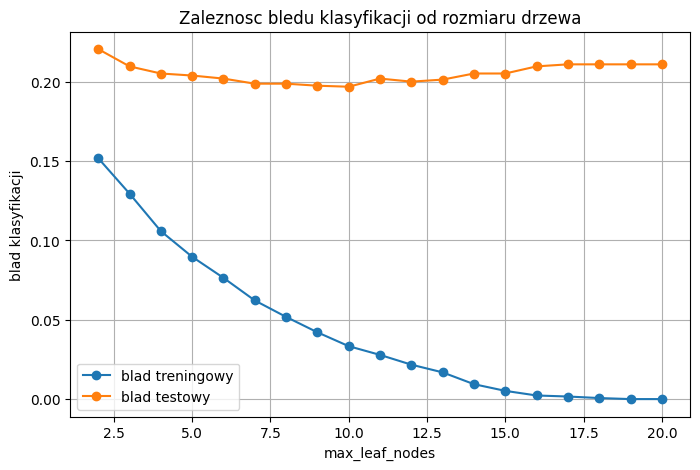

In [19]:
#Miejsce na rozwiązanie
leaf_sizes = range(2, 21)
train_errors = []
test_errors = []

for leaf_nodes in leaf_sizes:
    current_train_errors = []
    current_test_errors = []

    for seed in range(30):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=1/3, random_state=seed, stratify=y
        )

        mytree = tree.DecisionTreeClassifier(max_leaf_nodes=leaf_nodes, random_state=0)
        mytree.fit(X_train, y_train)

        current_train_errors.append(1 - mytree.score(X_train, y_train))
        current_test_errors.append(1 - mytree.score(X_test, y_test))

    train_errors.append(sum(current_train_errors) / len(current_train_errors))
    test_errors.append(sum(current_test_errors) / len(current_test_errors))

plt.figure(figsize=(8, 5))
plt.plot(list(leaf_sizes), train_errors, marker='o', label='blad treningowy')
plt.plot(list(leaf_sizes), test_errors, marker='o', label='blad testowy')

plt.xlabel('max_leaf_nodes')
plt.ylabel('blad klasyfikacji')
plt.title('Zaleznosc bledu klasyfikacji od rozmiaru drzewa')
plt.legend()
plt.grid(True)
plt.show()



# Lasy losowe #

Zobacz opis klasy `RandomForestClassifier`:

http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [21]:
from sklearn.ensemble import RandomForestClassifier

**Zadanie 6. (2 pkt)**

Dla zbioru danych *hepatitis* skonstruuj las losowy składający się z 20 drzew.

a) Jaki jest błąd klasyfikacji dla zbioru uczącego?

b) Jaki jest błąd klasyfikacji oszacowany w procesie walidacji krzyżowej?

c) Która klasa wykazuje najwyższą dokładność klasyfikacji, a która najniższą?

d) Jaki jest najczęstszy błąd (która klasa jest najczęściej mylona)?

In [22]:
#Miejsce na rozwiązanie
forest = RandomForestClassifier(n_estimators=20, random_state=0)

forest.fit(X, y)
train_error = 1 - forest.score(X, y)

cv_scores = cross_val_score(forest, X, y, cv=5)
cv_error = 1 - cv_scores.mean()

pred = cross_val_predict(forest, X, y, cv=5)
labels = ['DIE', 'LIVE']
cm = confusion_matrix(y, pred, labels=labels)

recalls = {}
for i, label in enumerate(labels):
    recalls[label] = cm[i, i] / cm[i].sum()

best_class = max(recalls, key=recalls.get)
worst_class = min(recalls, key=recalls.get)

max_error = -1
most_common_error = None
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j and cm[i, j] > max_error:
            max_error = cm[i, j]
            most_common_error = (labels[i], labels[j])

print("Błąd na zbiorze uczącym:", train_error)
print("Błąd w walidacji krzyżowej:", cv_error)
print("Macierz pomyłek:")
print(cm)
print("Recall klas:", recalls)
print("Najwyższa dokładność klasyfikacji:", best_class)
print("Najniższa dokładność klasyfikacji:", worst_class)
print("Najczęstszy błąd:", most_common_error[0], "->", most_common_error[1], ", liczba:", max_error)


Błąd na zbiorze uczącym: 0.0
Błąd w walidacji krzyżowej: 0.17419354838709677
Macierz pomyłek:
[[ 20  12]
 [ 15 108]]
Recall klas: {'DIE': np.float64(0.625), 'LIVE': np.float64(0.8780487804878049)}
Najwyższa dokładność klasyfikacji: LIVE
Najniższa dokładność klasyfikacji: DIE
Najczęstszy błąd: LIVE -> DIE , liczba: 15


**Zadanie 7. (1 pkt)**

Dla każdej klasy podaj dokładność klasyfikacji, tj. stosunek liczby poprawnie sklasyfikowanych przykładów danej klasy do wszystkich przykładów tej klasy. Jest to jeden z parametrów jakości klasyfikatora i nazywa się *recall*. Można go wyznaczyć korzystając z funkcji `recall_score` lub samodzielnie wyliczyć, korzystając z macierzy pomyłek. Wyznacz wartości *recall* na oba sposoby.

In [23]:
#Miejsce na rozwiązanie
from sklearn.metrics import recall_score

pred = cross_val_predict(forest, X, y, cv=5)
labels = sorted(y.unique())

recall_vals = recall_score(y, pred, labels=labels, average=None)
print("Recall z recall_score:")
for label, val in zip(labels, recall_vals):
    print(label, ":", val)

cm = confusion_matrix(y, pred, labels=labels)
print("\nMacierz pomyłek:")
print(cm)

print("\nRecall z macierzy pomyłek:")
for i, label in enumerate(labels):
    recall = cm[i, i] / cm[i].sum()
    print(label, ":", recall)


Recall z recall_score:
DIE : 0.625
LIVE : 0.8780487804878049

Macierz pomyłek:
[[ 20  12]
 [ 15 108]]

Recall z macierzy pomyłek:
DIE : 0.625
LIVE : 0.8780487804878049


**Zadanie 8. (1 pkt)**

Narysuj wykres przedstawiający zależność błędu klasyfikacji lasu losowego od liczby drzew w lesie. Oszacuj błąd klasyfikacji w 5-krotnej walidacji krzyżowej.

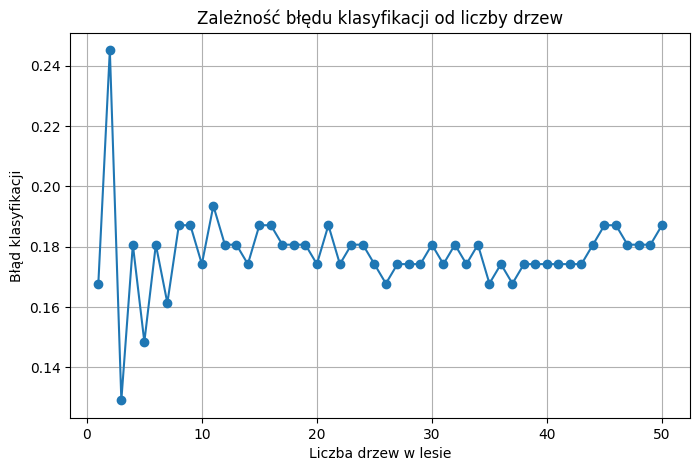

Najmniejszy błąd w 5-krotnej walidacji: 0.12903225806451624
Dla liczby drzew: 3


In [24]:
#Miejsce na rozwiązanie
n_trees = range(1, 51)
errors = []

for n in n_trees:
    forest = RandomForestClassifier(n_estimators=n, random_state=0)
    scores = cross_val_score(forest, X, y, cv=5)
    errors.append(1 - scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(list(n_trees), errors, marker='o')
plt.xlabel('Liczba drzew w lesie')
plt.ylabel('Błąd klasyfikacji')
plt.title('Zależność błędu klasyfikacji od liczby drzew')
plt.grid(True)
plt.show()

best_n = n_trees[errors.index(min(errors))]
best_error = min(errors)

print("Najmniejszy błąd w 5-krotnej walidacji:", best_error)
print("Dla liczby drzew:", best_n)


# Boosting

Zapoznaj się z opisem klasy:

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html


In [26]:
from sklearn.datasets import make_gaussian_quantiles

X, y = make_gaussian_quantiles(
    n_samples=2_000, n_features=10, n_classes=3, random_state=1
)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42
)

In [28]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

weak_learner = DecisionTreeClassifier(max_leaf_nodes=8)
n_estimators = 300

adaboost_clf = AdaBoostClassifier(
    estimator=weak_learner,
    n_estimators=n_estimators,
    random_state=42,
).fit(X_train, y_train)

**Zadanie 9. (1 pkt)**

Skorzystaj z walidacji krzyżowej, algorytmu AdaBoost dla danych *Iris* i drzewa decyzyjnego jako estymatora. Porównaj wynik z tymi otrzymanymi w zadaniu 3.

In [29]:
#Miejsce na rozwiązanie
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=0),
    n_estimators=50,
    random_state=0
)

scores_boost = cross_val_score(adaboost, iris.data, iris.target, cv=10)

print("AdaBoost - wyniki:", scores_boost)
print("AdaBoost - średnia dokładność: %0.4f (+/- %0.4f)" % (scores_boost.mean(), scores_boost.std() * 2))


AdaBoost - wyniki: [1.         0.93333333 1.         0.93333333 0.93333333 0.86666667
 0.93333333 0.93333333 1.         1.        ]
AdaBoost - średnia dokładność: 0.9533 (+/- 0.0854)
